In [22]:
!pip -q install --upgrade pip
!pip -q install -U "scikit-learn>=1.6,<1.7" "shap>=0.46.0" xgboost lightgbm catboost seaborn
print("Installed. If you just installed now: Runtime > Restart runtime")


Installed. If you just installed now: Runtime > Restart runtime


In [23]:
import sklearn, shap, xgboost, lightgbm, catboost
print("sklearn:", sklearn.__version__)
print("shap:", shap.__version__)
print("xgboost:", xgboost.__version__)
print("lightgbm:", lightgbm.__version__)
print("catboost:", catboost.__version__)


sklearn: 1.6.1
shap: 0.50.0
xgboost: 3.2.0
lightgbm: 4.6.0
catboost: 1.2.8


In [24]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    RepeatedStratifiedKFold,
    StratifiedKFold,
    RandomizedSearchCV,
    cross_validate
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import ExtraTreesClassifier, VotingClassifier, StackingClassifier


In [25]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("heart.csv")

print("Shape:", df.shape)
print("Columns:", list(df.columns))
df.head()


Saving heart.csv to heart (1).csv
Shape: (918, 12)
Columns: ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease']


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [26]:
#Detect target + build X, y
possible_targets = ["target", "Target", "label", "Label", "y", "Y", "output", "Outcome", "HeartDisease", "heart_disease"]
TARGET_COL = None
for c in possible_targets:
    if c in df.columns:
        TARGET_COL = c
        break

if TARGET_COL is None:
    TARGET_COL = df.columns[-1]  # fallback

print("Using TARGET_COL =", TARGET_COL)

y_raw = df[TARGET_COL]
X = df.drop(columns=[TARGET_COL])

# ensure binary 0/1
if y_raw.dtype == "object":
    y = y_raw.astype(str).str.strip().str.lower()
    map_dict = {"yes":1, "no":0, "true":1, "false":0, "1":1, "0":0, "positive":1, "negative":0}
    y = y.map(map_dict).astype(int)
else:
    y = y_raw.astype(int)

print("y unique:", sorted(pd.Series(y).unique()))


Using TARGET_COL = HeartDisease
y unique: [np.int64(0), np.int64(1)]


In [27]:
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

print("Numeric cols:", num_cols)
print("Categorical cols:", cat_cols)


Numeric cols: ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']
Categorical cols: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']


In [28]:
#Preprocessing pipelines
numeric_no_scale = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

numeric_scaled = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess_no_scale = ColumnTransformer(
    transformers=[
        ("num", numeric_no_scale, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ],
    remainder="drop"
)

preprocess_scaled = ColumnTransformer(
    transformers=[
        ("num", numeric_scaled, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ],
    remainder="drop"
)

print("✅ preprocess_no_scale & preprocess_scaled ready")


✅ preprocess_no_scale & preprocess_scaled ready


In [29]:
X_fe = X.copy()

# interactions (only if columns exist)
if "Age" in X_fe.columns and "Cholesterol" in X_fe.columns:
    X_fe["age_chol"] = X_fe["Age"] * X_fe["Cholesterol"]

if "Age" in X_fe.columns and "RestingBP" in X_fe.columns:
    X_fe["age_bp"] = X_fe["Age"] * X_fe["RestingBP"]

if "Cholesterol" in X_fe.columns and "FastingBS" in X_fe.columns:
    X_fe["chol_fbs"] = X_fe["Cholesterol"] * X_fe["FastingBS"]

if "Oldpeak" in X_fe.columns and "MaxHR" in X_fe.columns:
    X_fe["oldpeak_hr"] = X_fe["Oldpeak"] * X_fe["MaxHR"]

print("✅ Feature engineered shape:", X_fe.shape)
X_fe.head()


✅ Feature engineered shape: (918, 15)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,age_chol,age_bp,chol_fbs,oldpeak_hr
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,11560,5600,0,0.0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,8820,7840,0,156.0
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,10471,4810,0,0.0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,10272,6624,0,162.0
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,10530,8100,0,0.0


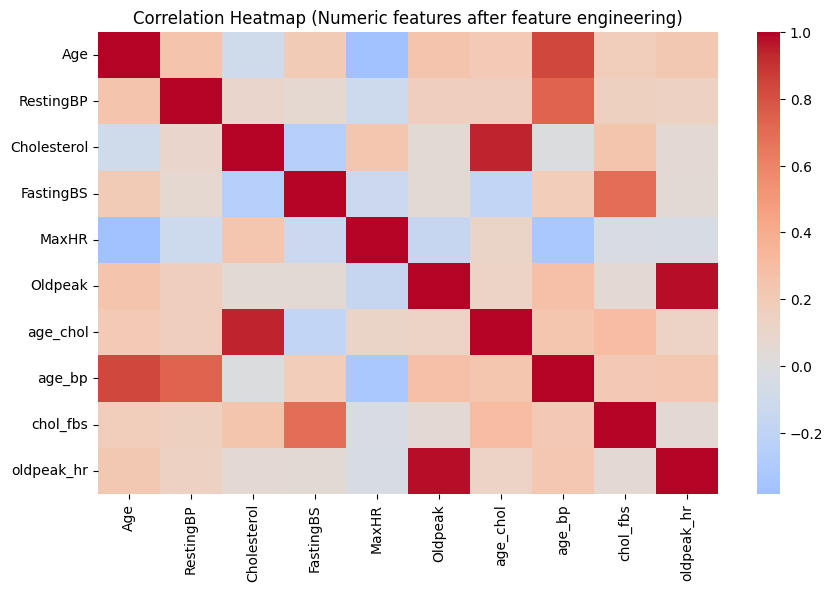

In [30]:
plt.figure(figsize=(10,6))
corr = X_fe.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (Numeric features after feature engineering)")
plt.show()


In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X_fe, y, test_size=0.20, random_state=42, stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (734, 15) Test: (184, 15)


In [32]:
# ----------------------------
# CELL 11 — Base model pipelines (ALL popular)
# ----------------------------

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# 1) Tree models (no scaling)
rf_pipe = Pipeline(steps=[
    ("prep", preprocess_no_scale),
    ("model", RandomForestClassifier(
        n_estimators=1200,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced_subsample"
    ))
])

et_pipe = Pipeline(steps=[
    ("prep", preprocess_no_scale),
    ("model", ExtraTreesClassifier(
        random_state=42,
        n_jobs=-1
    ))
])

gb_pipe = Pipeline(steps=[
    ("prep", preprocess_no_scale),
    ("model", GradientBoostingClassifier(random_state=42))
])

# 2) Linear models / SVM (need scaling)
lr_pipe = Pipeline(steps=[
    ("prep", preprocess_scaled),
    ("model", LogisticRegression(max_iter=5000, solver="lbfgs"))
])

svm_base = Pipeline(steps=[
    ("prep", preprocess_scaled),
    ("model", SVC(kernel="rbf", probability=False, class_weight="balanced", random_state=42))
])
svm_calibrated = CalibratedClassifierCV(estimator=svm_base, method="sigmoid", cv=5)

# 3) Boosting libraries
xgb_pipe = Pipeline(steps=[
    ("prep", preprocess_no_scale),
    ("model", XGBClassifier(
        n_estimators=800,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        eval_metric="logloss"
    ))
])

lgbm_pipe = Pipeline(steps=[
    ("prep", preprocess_no_scale),
    ("model", LGBMClassifier(
        n_estimators=1200,
        learning_rate=0.03,
        num_leaves=31,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42,
        n_jobs=-1
    ))
])

cat_pipe = Pipeline(steps=[
    ("prep", preprocess_no_scale),
    ("model", CatBoostClassifier(
        iterations=1200,
        learning_rate=0.03,
        depth=6,
        loss_function="Logloss",
        random_seed=42,
        verbose=False
    ))
])

# Put all base models in one dict (for evaluation + ROC later)
base_models = {
    "Logistic Regression": lr_pipe,
    "SVM (Calibrated)": svm_calibrated,
    "Random Forest": rf_pipe,
    "ExtraTrees": et_pipe,
    "Gradient Boosting": gb_pipe,
    "XGBoost": xgb_pipe,
    "LightGBM": lgbm_pipe,
    "CatBoost": cat_pipe
}

print("✅ Base pipelines ready:", list(base_models.keys()))


✅ Base pipelines ready: ['Logistic Regression', 'SVM (Calibrated)', 'Random Forest', 'ExtraTrees', 'Gradient Boosting', 'XGBoost', 'LightGBM', 'CatBoost']


In [33]:
# ----------------------------
#Compare all base models (Holdout test)
# ----------------------------

rows = []

for name, model in base_models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)
    p, r, f1, _ = precision_recall_fscore_support(y_test, pred, average="weighted", zero_division=0)

    rows.append({
        "Model": name,
        "Test Accuracy (%)": round(acc*100, 2),
        "Precision (weighted) (%)": round(p*100, 2),
        "Recall (weighted) (%)": round(r*100, 2),
        "F1 (weighted) (%)": round(f1*100, 2),
    })

# Comparison table (sorted by accuracy)
compare_df = pd.DataFrame(rows).sort_values("Test Accuracy (%)", ascending=False).reset_index(drop=True)
display(compare_df)

# Individual reports
for name, model in base_models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    print(f"\n==================== {name} ====================")
    print("Confusion Matrix:\n", confusion_matrix(y_test, pred))
    print("\nClassification Report:\n", classification_report(y_test, pred, zero_division=0))


[LightGBM] [Info] Number of positive: 406, number of negative: 328
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.037150 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 386
[LightGBM] [Info] Number of data points in the train set: 734, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.553134 -> initscore=0.213340
[LightGBM] [Info] Start training from score 0.213340
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[

,Model,Test Accuracy (%),Precision (weighted) (%),Recall (weighted) (%),F1 (weighted) (%)
0,SVM (Calibrated),90.22,90.25,90.22,90.19
1,Random Forest,90.22,90.25,90.22,90.19
2,ExtraTrees,89.13,89.15,89.13,89.10
3,Gradient Boosting,89.13,89.13,89.13,89.13
4,Logistic Regression,88.59,88.72,88.59,88.52
5,LightGBM,86.96,86.96,86.96,86.96
6,CatBoost,86.96,87.01,86.96,86.97
7,XGBoost,86.41,86.50,86.41,86.43



==================== Logistic Regression ====================
Confusion Matrix:
 [[68 14]
 [ 7 95]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.83      0.87        82
           1       0.87      0.93      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.88      0.88       184
weighted avg       0.89      0.89      0.89       184


==================== SVM (Calibrated) ====================
Confusion Matrix:
 [[71 11]
 [ 7 95]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.87      0.89        82
           1       0.90      0.93      0.91       102

    accuracy                           0.90       184
   macro avg       0.90      0.90      0.90       184
weighted avg       0.90      0.90      0.90       184


==================== Random Forest ====================
Confusion Matrix:
 [[71 11]
 [ 7 95]]

C

In [34]:
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)

et_params = {
    "model__n_estimators": [300, 600, 1000],
    "model__max_depth": [None, 5, 10, 15, 25],
    "model__min_samples_leaf": [1, 2, 4, 6],
    "model__max_features": ["sqrt", "log2", None, 0.6, 0.8]
}

lr_params = {
    "model__C": np.logspace(-3, 2, 20),
    "model__class_weight": [None, "balanced"]
}

svm_params = {
    "estimator__model__C": np.logspace(-2, 2, 20),
    "estimator__model__gamma": np.logspace(-4, 0, 20)
}

et_search = RandomizedSearchCV(et_pipe, et_params, n_iter=25, scoring="accuracy", cv=cv, random_state=42, n_jobs=-1, verbose=0)
lr_search = RandomizedSearchCV(lr_pipe, lr_params, n_iter=20, scoring="accuracy", cv=cv, random_state=42, n_jobs=-1, verbose=0)
svm_search = RandomizedSearchCV(svm_calibrated, svm_params, n_iter=25, scoring="accuracy", cv=cv, random_state=42, n_jobs=-1, verbose=0)

et_search.fit(X_train, y_train)
lr_search.fit(X_train, y_train)
svm_search.fit(X_train, y_train)

best_et = et_search.best_estimator_
best_lr = lr_search.best_estimator_
best_svm = svm_search.best_estimator_

print("Best ExtraTrees:", et_search.best_params_)
print("Best Logistic :", lr_search.best_params_)
print("Best CalSVM   :", svm_search.best_params_)


Best ExtraTrees: {'model__n_estimators': 300, 'model__min_samples_leaf': 4, 'model__max_features': 'log2', 'model__max_depth': 5}
Best Logistic : {'model__class_weight': None, 'model__C': np.float64(0.12742749857031335)}
Best CalSVM   : {'estimator__model__gamma': np.float64(0.0206913808111479), 'estimator__model__C': np.float64(5.455594781168514)}


In [35]:
voter = VotingClassifier(
    estimators=[
        ("et", best_et),
        ("svm", best_svm),
        ("lr", best_lr),
    ],
    voting="soft",
    n_jobs=-1
)

stack_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

stacker = StackingClassifier(
    estimators=[
        ("et", best_et),
        ("svm", best_svm),
        ("lr", best_lr),
    ],
    final_estimator=LogisticRegression(max_iter=5000),
    stack_method="predict_proba",
    cv=stack_cv,
    n_jobs=-1,
    passthrough=False
)

print("✅ voter + stacker ready")


✅ voter + stacker ready


In [36]:
def cv_eval(name, model):
    scoring = {"acc": "accuracy"}
    out = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    mean_acc = out["test_acc"].mean()
    std_acc = out["test_acc"].std()
    print(f"{name:12} | CV Accuracy: {mean_acc*100:.2f}% ± {std_acc*100:.2f}%")

print("\n--- CV Accuracy (Train only, repeated CV) ---")
cv_eval("Best_ET", best_et)
cv_eval("Best_LR", best_lr)
cv_eval("Best_SVM", best_svm)
cv_eval("SoftVote", voter)
cv_eval("Stacking", stacker)



--- CV Accuracy (Train only, repeated CV) ---
Best_ET      | CV Accuracy: 86.83% ± 3.15%
Best_LR      | CV Accuracy: 85.52% ± 2.93%
Best_SVM     | CV Accuracy: 85.92% ± 2.77%
SoftVote     | CV Accuracy: 86.56% ± 2.76%
Stacking     | CV Accuracy: 86.33% ± 2.94%


In [37]:
def holdout_report(name, model):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)
    p, r, f1, _ = precision_recall_fscore_support(y_test, pred, average="weighted", zero_division=0)

    print(f"\n========== {name} (Holdout Test) ==========")
    print(f"Accuracy : {acc*100:.2f}%")
    print(f"Precision: {p*100:.2f}%  Recall: {r*100:.2f}%  F1: {f1*100:.2f}%")
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, pred))
    print("\nClassification Report:\n", classification_report(y_test, pred, zero_division=0))

holdout_report("Best_ET", best_et)
holdout_report("Best_LR", best_lr)
holdout_report("Best_SVM", best_svm)
holdout_report("SoftVote", voter)
holdout_report("Stacking", stacker)



========== Best_ET (Holdout Test) ==========
Accuracy : 89.13%
Precision: 89.33%  Recall: 89.13%  F1: 89.06%

Confusion Matrix:
 [[68 14]
 [ 6 96]]

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.83      0.87        82
           1       0.87      0.94      0.91       102

    accuracy                           0.89       184
   macro avg       0.90      0.89      0.89       184
weighted avg       0.89      0.89      0.89       184


========== Best_LR (Holdout Test) ==========
Accuracy : 89.13%
Precision: 89.22%  Recall: 89.13%  F1: 89.08%

Confusion Matrix:
 [[69 13]
 [ 7 95]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.84      0.87        82
           1       0.88      0.93      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.89      0.89       184
weighted avg       0.89      0.89      0.89       184

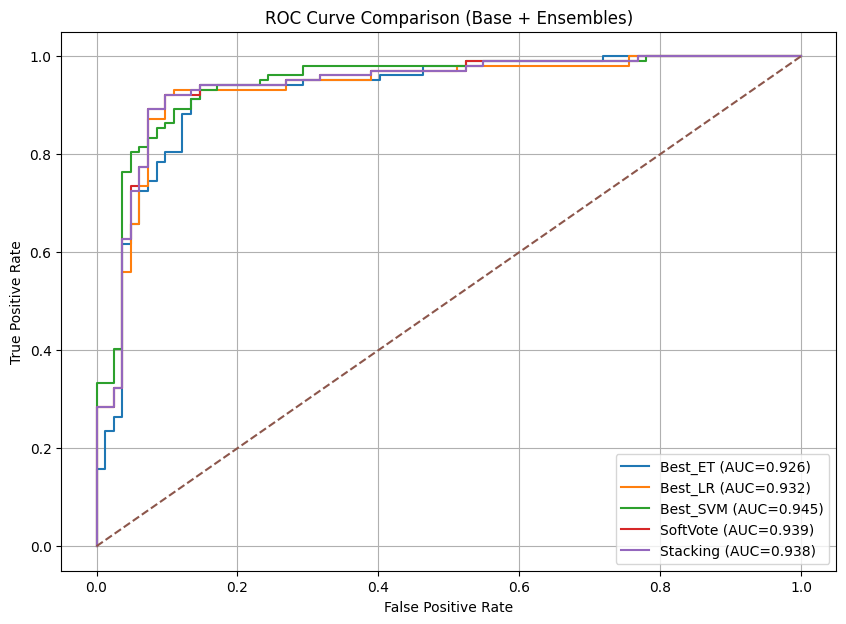

In [38]:
#ROC curve comparison (base + ensembles)

plt.figure(figsize=(10,7))

roc_models = {
    "Best_ET": best_et,
    "Best_LR": best_lr,
    "Best_SVM": best_svm,
    "SoftVote": voter,
    "Stacking": stacker
}

for name, model in roc_models.items():
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")

plt.plot([0,1],[0,1],"--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison (Base + Ensembles)")
plt.legend()
plt.grid(True)
plt.show()


In [39]:
#Threshold tuning

best_model = voter   # or stacker if stacker was better for you
best_model.fit(X_train, y_train)

proba = best_model.predict_proba(X_test)[:, 1]

best_acc = 0
best_thr = 0.5

for thr in np.arange(0.30, 0.71, 0.01):
    preds = (proba >= thr).astype(int)
    acc = accuracy_score(y_test, preds)
    if acc > best_acc:
        best_acc = acc
        best_thr = thr

print("Best Threshold:", round(best_thr, 2))
print("Best Accuracy :", round(best_acc*100, 2), "%")


Best Threshold: 0.58
Best Accuracy : 91.3 %


In [40]:
final_preds = (proba >= best_thr).astype(int)

print("\n========== FINAL MODEL (Threshold tuned) ==========")
print("Model:", "SoftVote" if best_model == voter else "Stacking")
print("Threshold:", round(best_thr, 2))
print("Test Accuracy:", round(accuracy_score(y_test, final_preds)*100, 2), "%")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, final_preds))
print("\nClassification Report:\n", classification_report(y_test, final_preds, zero_division=0))



========== FINAL MODEL (Threshold tuned) ==========
Model: SoftVote
Threshold: 0.58
Test Accuracy: 91.3 %

Confusion Matrix:
 [[74  8]
 [ 8 94]]

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.90      0.90        82
           1       0.92      0.92      0.92       102

    accuracy                           0.91       184
   macro avg       0.91      0.91      0.91       184
weighted avg       0.91      0.91      0.91       184



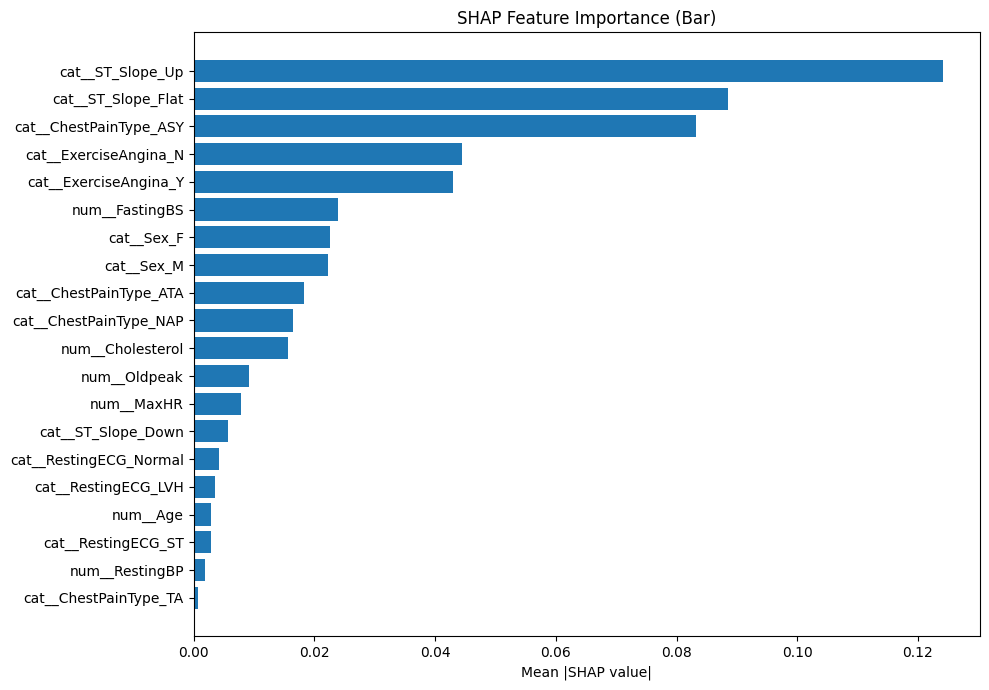

In [41]:
import shap
import matplotlib.pyplot as plt
import numpy as np

# Fit model
best_et.fit(X_train, y_train)

prep = best_et.named_steps["prep"]
model = best_et.named_steps["model"]

X_test_trans = prep.transform(X_test)
feature_names = np.array(prep.get_feature_names_out())

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_trans)

# ---------- normalize shap_values to 2D: (n_samples, n_features) ----------
if isinstance(shap_values, list):
    # old style: list of arrays per class
    shap_2d = shap_values[1]  # class 1
else:
    shap_arr = np.array(shap_values)

    if shap_arr.ndim == 3:
        # shape could be (n_samples, n_classes, n_features) OR (n_samples, n_features, n_classes)
        # pick the axis that equals 2 as class axis
        if shap_arr.shape[1] == 2:
            shap_2d = shap_arr[:, 1, :]     # class 1
        elif shap_arr.shape[2] == 2:
            shap_2d = shap_arr[:, :, 1]     # class 1
        else:
            # fallback: average over middle axis
            shap_2d = shap_arr.mean(axis=1)
    else:
        # already (n_samples, n_features)
        shap_2d = shap_arr

# ---------- mean absolute shap per feature ----------
mean_abs_shap = np.abs(shap_2d).mean(axis=0)

# sort + plot
sorted_idx = np.argsort(mean_abs_shap)

plt.figure(figsize=(10, 7))
plt.barh(range(len(sorted_idx)), mean_abs_shap[sorted_idx])
plt.yticks(range(len(sorted_idx)), feature_names[sorted_idx])
plt.xlabel("Mean |SHAP value|")
plt.title("SHAP Feature Importance (Bar)")
plt.tight_layout()
plt.show()
